In [1]:
# Cell 1: Setup

import tensorflow as tf
from tensorflow import keras                # type: ignore
from tensorflow.keras import layers         # type: ignore
import numpy as np
import matplotlib.pyplot as plt
import math

# GPU configuration for better performance and stability
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)
    tf.config.optimizer.set_jit(True)

keras.mixed_precision.set_global_policy('mixed_float16')

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")
print(f"Compute dtype: {keras.mixed_precision.global_policy().compute_dtype}")

np.random.seed(42)
tf.random.set_seed(42)


# Constants / Hyperparameters
LATENT_DIM      = 16
KL_WEIGHT       = 1.0
KL_STEEPNESS    = 0.2
LOCAL_WEIGHT    = 0.1               # if unstable: lower to 0.1 (usually results in better generations, worse reconstructions), if weak: increase to 2.0
BATCH_SIZE      = 512
BASE_FILTERS    = 16
LEARNING_RATE   = 0.001
LR_DECAY        = 0.75
WEIGHT_DECAY    = 0.0005
CLIPNORM        = 2.0
EPOCHS          = 250
                                    # BOTTLENECK_DIM * BOTTLENECK_DIM * LATENT_DIM should not > CIFAR-10 Input, which is 32x32x3=3072
                                    # BOTTLENECK_DIM = 8, LATENT_DIM = 64 and 8x8x64=4096, which > 3072, so VAE memorises and adds noise instead of learning compression  
BOTTLENECK_DIM  = 4
MAX_LAYERS      = 4
LOSS_FUNCTION   = str('mse')        # 'mse' or 'bce'
ACTIVATION_OUT  = str('tanh')       # 'tanh' or 'sigmoid'

IMAGE_SIZE_X    = 32
IMAGE_SIZE_Y    = 32
CHANNELS        = 3                 # 1 for grayscale, 3 for RGB
STRIDE          = 2

STAGE_EPOCHS    = int(EPOCHS // MAX_LAYERS)
WARMUP_EPOCHS   = int(STAGE_EPOCHS // 10)
AES_PATIENCE    = 10
AES_SENSITIVITY = 0.075             # Lower is more sensitive
AES_MIN_DELTA   = 0.01
AES_START_EPOCH = int(STAGE_EPOCHS * 0.5)

2026-05-01 14:20:28.711267: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-01 14:20:29.417968: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-01 14:20:31.833463: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Compute dtype: float16


In [ ]:
# Cell 2: Architecture

class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = keras.random.normal(shape=keras.ops.shape(z_mean), dtype=z_mean.dtype)
        return z_mean + keras.ops.exp(0.5 * z_log_var) * epsilon


class LocalEncoder(keras.Model):
    def __init__(self, num_layers, latent_dim=LATENT_DIM, **kwargs):
        super().__init__(name=f'encoder_L{num_layers}', **kwargs)
        self.num_layers = num_layers
        self.conv_blocks = []
        max_down = int(math.log2(IMAGE_SIZE_X // BOTTLENECK_DIM))
        self.num_down = min(num_layers, max_down)

        for i in range(num_layers):
            filters = BASE_FILTERS * (2 ** i)
            stride  = STRIDE if i < self.num_down else 1
            block = keras.Sequential([
                layers.Conv2D(filters, 3, strides=stride, padding='same', activation='relu', use_bias=False, name=f'enc_conv_{i}'),
                layers.Conv2D(filters, 1, padding='same', activation='relu', use_bias=False, name=f'enc_1x1_{i}'),
            ], name=f'enc_block_{i}')
            self.conv_blocks.append(block)

        self.z_mean_layer    = layers.Conv2D(latent_dim, 3, padding='same', name='z_mean',    dtype='float32')
        self.z_log_var_layer = layers.Conv2D(latent_dim, 3, padding='same', name='z_log_var', dtype='float32')
        self.sampling        = Sampling()

    def call(self, inputs, training=False):
        x           = inputs
        activations = []
        for block in self.conv_blocks:
            x = block(x, training=training)
            activations.append(x)
            x = tf.stop_gradient(x)     # Local learning, no gradient flows between blocks

        # Bottleneck only sees the innermost block's representation
        z_mean    = self.z_mean_layer(x)
        z_log_var = self.z_log_var_layer(x)
        z         = self.sampling([z_mean, z_log_var])
        return [z_mean, z_log_var, z] + activations

    def get_layer(self, name):
        # Support transfer_weights and freeze_outer by searching sub-layers
        for block in self.conv_blocks:
            for layer in block.layers:
                if layer.name == name:
                    return layer
        for layer in [self.z_mean_layer, self.z_log_var_layer, self.sampling]:
            if layer.name == name:
                return layer
        raise ValueError(f'No layer named {name}')


def build_decoder(num_layers, latent_dim=LATENT_DIM):
    max_down = int(math.log2(IMAGE_SIZE_X // BOTTLENECK_DIM))
    num_down = min(num_layers, max_down)
    current_size = IMAGE_SIZE_X // (2 ** num_down)

    inputs = keras.Input(shape=(current_size, current_size, latent_dim))
    proj_filters = BASE_FILTERS * (2 ** (num_layers - 1))
    x = layers.Conv2D(proj_filters, 1, padding='same', activation='relu', use_bias=False, name='dec_input_proj')(inputs)

    total_blocks = max(num_layers, max_down)
    for i in range(total_blocks - 1, -1, -1):
        filters = BASE_FILTERS * (2 ** min(i, num_layers - 1))
        stride  = STRIDE if i < num_down else 1

        # 1x1 conv to mix channels before upsampling (mirror of encoder)
        x = layers.Conv2D(filters, 1, padding='same', activation='relu', use_bias=False, name=f'dec_1x1_{i}')(x)
        
        # NxN transpose conv to upsample
        x = layers.Conv2DTranspose(filters, 3, strides=stride, padding='same', activation='relu', use_bias=False, name=f'dec_convT_{i}')(x)

    outputs = layers.Conv2D(CHANNELS, 3, padding='same', activation=ACTIVATION_OUT, dtype='float32', name='dec_output')(x)

    return keras.Model(inputs, outputs, name=f'decoder_L{num_layers}')


def build_local_head(in_channels, out_channels, upsample=False):
    head_layers = []
    if upsample:
        head_layers.append(layers.Conv2DTranspose(out_channels, 3, strides=2, padding='same', activation='relu'))
    else:
        head_layers.append(layers.Conv2D(out_channels, 3, padding='same', activation='relu'))
    head_layers.append(layers.Conv2D(out_channels, 1, padding='same', activation=None))
    return keras.Sequential(head_layers)


def freeze_outer(encoder, decoder, n_frozen_blocks):

    # Freeze the n_frozen_blocks outermost encoder and decoder blocks.
    # These are the blocks from the previous training stage.
    # Targets layers by name so it's precise regardless of model size.

    enc_prefixes = ['enc_conv', 'enc_1x1']
    dec_prefixes = ['dec_1x1', 'dec_convT']
    
    frozen_enc = []
    frozen_dec = []
    
    # Freeze earliest encoder blocks (outermost = closest to input)
    # Index 0 is earliest block for encoder and last for decoder
    for i in range(n_frozen_blocks):
        for p in enc_prefixes:
            name = f'{p}_{i}'
            layer = encoder.get_layer(name) if name in [l.name for l in encoder.layers] else None
            if layer:
                layer.trainable = False
                frozen_enc.append(name)

    # Freeze earliest decoder blocks (outermost = closest to output reconstruction)
    for i in range(n_frozen_blocks):
        for p in dec_prefixes:
            name = f'{p}_{i}'
            layer = decoder.get_layer(name) if name in [l.name for l in decoder.layers] else None
            if layer:
                layer.trainable = False
                frozen_dec.append(name)
                
    print(f'[Freeze] Encoder frozen: {frozen_enc}')
    print(f'[Freeze] Decoder frozen: {frozen_dec}')

       
def transfer_weights(old_model, new_model):

    transferred = 0
    skipped = []
    skip_layers = {'z_mean', 'z_log_var'}

    old_layers = {l.name: l for l in old_model.layers}
    for new_layer in new_model.layers:
        if not new_layer.weights:
            continue
        if new_layer.name not in old_layers:
            continue
        if new_layer.name in skip_layers:
            continue

        old_layer = old_layers[new_layer.name]

        old_w = old_layer.get_weights()
        new_w = new_layer.get_weights()

        # Check same number of tensors
        if len(old_w) != len(new_w):
            skipped.append(f"{new_layer.name} (count mismatch)")
            continue

        # Check shape match
        if any(ow.shape != nw.shape for ow, nw in zip(old_w, new_w)):
            skipped.append(f"{new_layer.name} (shape mismatch)")
            continue

        new_layer.set_weights(old_w)
        transferred += 1

    print(f'[Weights] transferred={transferred}, skipped={len(skipped)}')
    if skipped: print(f'[Weights] skipped layers: {skipped[:5]}...')

    return transferred


class VAE(keras.Model):
    def __init__(self, encoder, decoder, num_layers, kl_weight_var, **kwargs):
        super().__init__(**kwargs)
        self.encoder       = encoder
        self.decoder       = decoder
        self.kl_weight_var = tf.Variable(kl_weight_var, trainable=False, dtype=tf.float32)
        self.local_heads = []
        max_down = int(math.log2(IMAGE_SIZE_X // BOTTLENECK_DIM))
        for i in range(1, num_layers):
            in_ch    = BASE_FILTERS * (2 ** i)
            out_ch   = BASE_FILTERS * (2 ** (i - 1))
            upsample = (i < max_down)          # only upsample where encoder actually downsampled
            self.local_heads.append(build_local_head(in_ch, out_ch, upsample=upsample))

        self._loss_tracker       = keras.metrics.Mean(name='loss')
        self._recon_loss_tracker = keras.metrics.Mean(name='recon_loss')
        self._kl_loss_tracker    = keras.metrics.Mean(name='kl_loss')
        self._local_loss_tracker = keras.metrics.Mean(name='local_loss')

    @property
    def metrics(self):
        return [self._loss_tracker, self._recon_loss_tracker, self._kl_loss_tracker, self._local_loss_tracker]

    def call(self, x):
        outputs = self.encoder(x)
        z_mean, z_log_var, z = outputs[:3]
        return self.decoder(z)

    def _compute_losses(self, x, reconstruction, z_mean, z_log_var):
        x              = tf.cast(x,              tf.float32)
        reconstruction = tf.cast(reconstruction, tf.float32)
        z_mean         = tf.cast(z_mean,         tf.float32)
        z_log_var      = tf.cast(z_log_var,      tf.float32)
        if LOSS_FUNCTION == 'bce':
            recon_loss = tf.reduce_mean(tf.reduce_sum(keras.losses.binary_crossentropy(x, reconstruction), axis=[1, 2]))
        elif LOSS_FUNCTION == 'mse':
            # Calculate MSE per image (not pixel), then average over batch (use instead of MeanSquaredError for VAEs)
            recon_loss = tf.reduce_mean(tf.reduce_sum(tf.square(x - reconstruction), axis=[1, 2, 3]))
        kl_loss = -0.5 * tf.reduce_mean(tf.reduce_sum(1.0 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=[1, 2, 3]))
        total_loss = recon_loss + tf.cast(self.kl_weight_var, tf.float32) * kl_loss
        return total_loss, recon_loss, kl_loss

    def _update_metrics(self, total, recon, kl, local=0.0):
        self._loss_tracker.update_state(total)
        self._recon_loss_tracker.update_state(recon)
        self._kl_loss_tracker.update_state(kl)
        self._local_loss_tracker.update_state(local)
        return {
            'loss':       self._loss_tracker.result(),
            'recon_loss': self._recon_loss_tracker.result(),
            'kl_loss':    self._kl_loss_tracker.result(),
            'local_loss': self._local_loss_tracker.result(),
        }

    def train_step(self, data):
        x, _ = data
        with tf.GradientTape() as tape:
            outputs                             = self.encoder(x, training=True)
            z_mean, z_log_var, z                = outputs[:3]
            activations                         = outputs[3:]
            reconstruction                      = self.decoder(z, training=True)
            total, recon, kl                    = self._compute_losses(x, reconstruction, z_mean, z_log_var)
            # Local Losses
            local_loss = 0.0
            for i in range(1, len(activations)):
                h_prev    = activations[i-1]
                h_current = activations[i]
                # Optional (more biologically correct)
                h_prev = tf.stop_gradient(h_prev)
                recon_prev = self.local_heads[i-1](h_current)
                if recon_prev.shape[1] != h_prev.shape[1]:
                    recon_prev = tf.image.resize(recon_prev, tf.shape(h_prev)[1:3])
                h_prev     = tf.cast(h_prev, tf.float32)
                recon_prev = tf.cast(recon_prev, tf.float32)
                local_loss += tf.cast(tf.reduce_mean(tf.reduce_sum(tf.square(h_prev - recon_prev), axis=[1,2,3])), tf.float32)
            # Combine losses
            total = tf.cast(total, tf.float32) + LOCAL_WEIGHT * local_loss
        grads = tape.gradient(total, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        return self._update_metrics(total, recon, kl, local_loss)

    def test_step(self, data):
        x, _ = data
        outputs                         = self.encoder(x, training=False)
        z_mean, z_log_var, z            = outputs[:3]
        activations                     = outputs[3:]
        reconstruction                  = self.decoder(z, training=False)
        total, recon, kl                = self._compute_losses(x, reconstruction, z_mean, z_log_var)
        local_loss = 0.0
        for i in range(1, len(activations)):
            h_prev     = tf.cast(tf.stop_gradient(activations[i-1]), tf.float32)
            h_current  = activations[i]
            recon_prev = self.local_heads[i-1](h_current, training=False)
            if recon_prev.shape[1] != h_prev.shape[1]:
                recon_prev = tf.image.resize(recon_prev, tf.shape(h_prev)[1:3])
            recon_prev = tf.cast(recon_prev, tf.float32)
            local_loss += tf.reduce_mean(tf.reduce_sum(tf.square(h_prev - recon_prev), axis=[1,2,3]))
        total = tf.cast(total, tf.float32) + LOCAL_WEIGHT * local_loss
        return self._update_metrics(total, recon, kl, local_loss)

In [3]:
# Cell 3: Custom Callbacks

class KLAnneal(keras.callbacks.Callback):
    # Sigmoid KL annealing: smoothly increases KL weight from near-0 to weight_target over warmup_epochs
    def __init__(self, weight_target = KL_WEIGHT, warmup_epochs=STAGE_EPOCHS, steepness=0.2, verbose=True):
        super().__init__()
        self.kl_weight_target = weight_target
        self.warmup_epochs    = warmup_epochs
        self.steepness        = steepness
        self.verbose          = verbose
        self.epoch_offset     = 0

    def on_epoch_begin(self, epoch, logs=None):
        global_epoch = epoch + self.epoch_offset
        midpoint   = self.warmup_epochs / 2
        progress   = (global_epoch - midpoint) / (self.steepness * self.warmup_epochs)
        new_weight = self.kl_weight_target / (1.0 + math.exp(-progress))
        self.model.kl_weight_var.assign(new_weight)
        if self.verbose and epoch < self.warmup_epochs:
            print(f'[KLAnneal] Global Epoch {global_epoch + 1} | KL Weight = {new_weight:.5f}')


class AdaptiveEarlyStopping(keras.callbacks.Callback):
    # Early stopping but patience shrinks after relative LR reductions not a set number
    def __init__(self, monitor='val_loss', base_patience=7, min_delta=0.1, patience_decay=0.7, min_patience=3, 
                    start_epoch=0, triggered=False, restore_best_weights=True, verbose=True):
        super().__init__()
        self.monitor              = monitor
        self.base_patience        = base_patience
        self.current_patience     = base_patience
        self.min_delta            = min_delta
        self.patience_decay       = patience_decay
        self.min_patience         = min_patience
        self.start_epoch          = start_epoch
        self.restore_best_weights = restore_best_weights
        self.verbose              = verbose
        self.best                 = np.inf
        self.wait                 = 0
        self.best_weights         = None
        self._prev_lr             = None

    def on_train_begin(self, logs=None):
        self.best             = np.inf
        self.wait             = 0
        self.best_weights     = None
        self.current_patience = self.base_patience
        self._prev_lr         = float(keras.backend.get_value(self.model.optimizer.learning_rate))

    def on_epoch_end(self, epoch, logs=None):
        if epoch < self.start_epoch:
            return
        logs    = logs or {}
        current = logs.get(self.monitor)
        
        if current is None:
            return
        current_lr = float(keras.backend.get_value(self.model.optimizer.learning_rate))
        
        if self._prev_lr is not None:
            relative_drop = (self._prev_lr - current_lr) / (self._prev_lr + 1e-10)
            if relative_drop > AES_SENSITIVITY:
                self.current_patience = max(self.min_patience, int(self.current_patience * self.patience_decay))
                if self.verbose:
                    print(f'[AdaptiveES] LR dropped {self._prev_lr:.5f} -> {current_lr:.5f}; patience -> {self.current_patience}')
        self._prev_lr = current_lr
        
        if current < self.best - self.min_delta:
            self.best         = current
            self.wait         = 0
            self.best_weights = self.model.get_weights()
        else:
            self.wait += 1
            if self.verbose:
                print(f'[AdaptiveES] No improvement for {self.wait}/{self.current_patience} epochs (best={self.best:.4f})')
            if self.wait >= self.current_patience:
                self.model.stop_training = True
                if self.restore_best_weights and self.best_weights is not None:
                    if self.verbose:
                        print('[AdaptiveES] Restoring best weights.')
                    self.model.set_weights(self.best_weights)


class EfficientModelCheckpoint(keras.callbacks.ModelCheckpoint):
    # ModelCheckpoint that only saves the best weights taken from AdaptiveEarlyStopping
    def __init__(self, aes_callback, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.aes_callback = aes_callback

    def on_epoch_end(self, epoch, logs=None):
        pass    # do nothing

    def on_train_end(self, logs=None):
        current_weights = self.model.get_weights()  
        if self.aes_callback.best_weights is not None:
            if self.verbose:
                print(f"[EffCheck] Saving best weights from AdaptiveEarlyStopping to {self.filepath}")
            if not self.aes_callback.restore_best_weights:
                # Temporarily load best weights into model if AES isn't restored
                self.model.set_weights(self.aes_callback.best_weights)
                # Save them
                self.model.save_weights(self.filepath)
                # Restore current weights (optional but clean)
                self.model.set_weights(current_weights)
            else:
                self.model.save_weights(self.filepath)
        else:
            if self.verbose:
                print(f"[EffCheck] No best weights found, saving current model weights.")
            self.model.save_weights(self.filepath)

In [4]:
# Cell 4: Data Pipeline and Training

(x_train, _), (x_test, _) = keras.datasets.cifar10.load_data()

if ACTIVATION_OUT == 'sigmoid':
    x_train = (x_train.astype('float32') / 255.0)
    x_test  = (x_test.astype('float32')  / 255.0)
else:   # ACTIVATION_OUT == 'tanh'
    x_train = (x_train.astype('float32') / 127.5) - 1.0
    x_test  = (x_test.astype('float32')  / 127.5) - 1.0

print(f'Training data: {x_train.shape}')
print(f'Test data:     {x_test.shape}')


@tf.function
def augment(x, _):
    x = tf.image.random_flip_left_right(x)
    x = tf.image.random_brightness(x, 0.1)
    x = tf.image.random_contrast(x, 0.9, 1.1)
    clip_min = 0.0 if ACTIVATION_OUT == 'sigmoid' else -1.0     # -1.0 for tanh
    x = tf.clip_by_value(x, clip_min, 1.0)
    return x, x

train_dataset = (
    tf.data.Dataset.from_tensor_slices((x_train, x_train))
    .shuffle(len(x_train))
    .map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    .cache()
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_dataset = (
    tf.data.Dataset.from_tensor_slices((x_test, x_test))
    .cache()
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# Cosine decay: gradually lowers LR exponentially until early stopping triggers
# Generally outperforms ReduceLROnPlateau for image generation tasks 
steps_per_epoch = len(x_train) // BATCH_SIZE
def lr_schedule():
    # Fresh schedule each stage so LR starts from the beginning of the warmup curve each stage
    return keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=LEARNING_RATE / 2,
        decay_steps=(STAGE_EPOCHS * steps_per_epoch) / LR_DECAY,
        alpha=1e-5,    # minimum LR at end of cosine decay
        warmup_target=LEARNING_RATE,
        warmup_steps=WARMUP_EPOCHS * steps_per_epoch
    )


# Callbacks

# Lambda uses vae from outer scope, in Python closures capture the variable name not the value, so this always reads the current vae
print_lr = keras.callbacks.LambdaCallback(
    on_epoch_begin=lambda epoch, logs: print(f'\n[Learning Rate]: {float(keras.backend.get_value(vae.optimizer.learning_rate)):.5f}')
)

kl_anneal  = KLAnneal(weight_target=KL_WEIGHT, warmup_epochs=STAGE_EPOCHS, steepness=KL_STEEPNESS, verbose=True)

early_stop = AdaptiveEarlyStopping(
    monitor='val_loss',
    base_patience=AES_PATIENCE,
    min_delta=AES_MIN_DELTA,
    start_epoch=AES_START_EPOCH,
    verbose=True
)

csv_logger = keras.callbacks.CSVLogger('training_log.csv', append=True)

histories        = []
previous_encoder = None
previous_decoder = None

for stage_layers in range(1, MAX_LAYERS + 1):

    print(f'\n{"="*50}')
    print(f'Training Stage: {stage_layers} / {MAX_LAYERS}')
    print(f'{"="*50}\n')

    encoder = LocalEncoder(stage_layers)
    decoder = build_decoder(stage_layers)

    if previous_encoder is not None:
        print('Transferring weights from previous stage...')
        transfer_weights(previous_encoder, encoder)
        transfer_weights(previous_decoder, decoder)
        
        # Pass stage_layers so the decoder knows its max index
        print(f'Freezing {stage_layers-1} outer block(s)...')
        freeze_outer(encoder, decoder, stage_layers-1)

    vae = VAE(encoder, decoder, stage_layers, kl_weight_var=KL_WEIGHT)

    # Fresh LR schedule + optimizer each stage
    lr_optimizer = keras.optimizers.AdamW(
        learning_rate=lr_schedule(),  # Call function to get a new schedule instance each stage
        weight_decay=WEIGHT_DECAY,
        clipnorm=CLIPNORM,
    )
    
    vae.compile(optimizer=lr_optimizer)
    
    # After building stage N model, verify layer names:
    print("Encoder layers:", [l.name for l in encoder.layers if 'enc_' in l.name][:10])
    print("Decoder layers:", [l.name for l in decoder.layers if 'dec_' in l.name][:10])

    # After freezing, verify trainable status:
    enc_trainable = [l.name for l in encoder.layers if 'enc_' in l.name and l.trainable]
    dec_trainable = [l.name for l in decoder.layers if 'dec_' in l.name and l.trainable]
    print(f"[Freeze] Remaining trainable encoder layers: {enc_trainable}")
    print(f"[Freeze] Remaining trainable decoder layers: {dec_trainable}")

    # Before training stage N, check trainable param count:
    trainable_count = np.sum([np.prod(v.shape) for v in vae.trainable_weights])
    print(f"Trainable params for stage {stage_layers}: {trainable_count:,}")
    
    # Build model before fit so checkpoint callback doesn't break
    vae(tf.zeros((1, IMAGE_SIZE_X, IMAGE_SIZE_Y, CHANNELS)))

    checkpoint = EfficientModelCheckpoint(
        early_stop,
        f'vae_stage{stage_layers}_best.weights.h5',
        verbose=1,
    )

    print('Starting training.')
    history = vae.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=STAGE_EPOCHS,
        verbose=2,
        callbacks=[print_lr, kl_anneal, early_stop, checkpoint, csv_logger]     # early_stop must come before checkpoint
    )

    previous_encoder = encoder
    previous_decoder = decoder
    histories.append(history.history)
    kl_anneal.epoch_offset += len(history.history['loss'])      # To account for early stopping as well

/home/username/tf-env/lib/python3.12/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


Training data: (50000, 32, 32, 3)
Test data:     (10000, 32, 32, 3)


I0000 00:00:1777641637.956054   23632 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5560 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9



Training Stage: 1 / 4

Encoder layers: ['enc_block_0']
Decoder layers: ['dec_input_proj', 'dec_1x1_2', 'dec_convT_2', 'dec_1x1_1', 'dec_convT_1', 'dec_1x1_0', 'dec_convT_0', 'dec_output']
[Freeze] Remaining trainable encoder layers: ['enc_block_0']
[Freeze] Remaining trainable decoder layers: ['dec_input_proj', 'dec_1x1_2', 'dec_convT_2', 'dec_1x1_1', 'dec_convT_1', 'dec_1x1_0', 'dec_convT_0', 'dec_output']
Trainable params for stage 1: 8,371


2026-05-01 14:20:43.896938: E tensorflow/core/util/util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.
2026-05-01 14:20:44.052266: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900


...

Starting training.

[Learning Rate]: 0.00050
[KLAnneal] Global Epoch 43 | KL Weight = 0.70829
Epoch 1/62
98/98 - 23s - 240ms/step - kl_loss: 6.2076 - local_loss: 16.5378 - loss: 708.7750 - recon_loss: 702.7245 - val_kl_loss: 32.9580 - val_local_loss: 11.3738 - val_loss: 495.1217 - val_recon_loss: 470.6404

[Learning Rate]: 0.00058
[KLAnneal] Global Epoch 44 | KL Weight = 0.72467
Epoch 2/62
98/98 - 1s - 11ms/step - kl_loss: 47.7477 - local_loss: 9.8853 - loss: 432.6896 - recon_loss: 397.0999 - val_kl_loss: 56.7656 - val_local_loss: 8.4527 - val_loss: 391.4258 - val_recon_loss: 349.4443

[Learning Rate]: 0.00067
[KLAnneal] Global Epoch 45 | KL Weight = 0.74047
Epoch 3/62
98/98 - 1s - 11ms/step - kl_loss: 63.6015 - local_loss: 7.4392 - loss: 369.3659 - recon_loss: 321.5273 - val_kl_loss: 68.5942 - val_local_loss: 6.3859 - val_loss: 353.8380 - val_recon_loss: 302.4079

[Learning Rate]: 0.00075
[KLAnneal] Global Epoch 46 | KL Weight = 0.75566
Epoch 4/62
98/98 - 1s - 11ms/step - kl_loss: 72.

/home/username/tf-env/lib/python3.12/site-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'vae_2', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


98/98 - 20s - 201ms/step - kl_loss: 0.1740 - local_loss: 68.8479 - loss: 778.7076 - recon_loss: 771.6492 - val_kl_loss: 0.3823 - val_local_loss: 50.4444 - val_loss: 764.3869 - val_recon_loss: 758.9611

[Learning Rate]: 0.00058
[KLAnneal] Global Epoch 106 | KL Weight = 0.99745
Epoch 2/62
98/98 - 1s - 11ms/step - kl_loss: 5.9765 - local_loss: 44.4826 - loss: 721.5191 - recon_loss: 711.1099 - val_kl_loss: 19.0001 - val_local_loss: 37.6191 - val_loss: 644.9264 - val_recon_loss: 622.2129

[Learning Rate]: 0.00067
[KLAnneal] Global Epoch 107 | KL Weight = 0.99764
Epoch 3/62
98/98 - 1s - 12ms/step - kl_loss: 27.1821 - local_loss: 30.7847 - loss: 580.3911 - recon_loss: 550.1946 - val_kl_loss: 28.3891 - val_local_loss: 24.8543 - val_loss: 531.1195 - val_recon_loss: 500.3119

[Learning Rate]: 0.00075
[KLAnneal] Global Epoch 108 | KL Weight = 0.99783
Epoch 4/62
98/98 - 1s - 12ms/step - kl_loss: 34.4722 - local_loss: 21.9085 - loss: 489.6136 - recon_loss: 453.0254 - val_kl_loss: 39.0154 - val_loca

/home/username/tf-env/lib/python3.12/site-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'vae_3', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


98/98 - 27s - 271ms/step - kl_loss: 0.0114 - local_loss: 42.9522 - loss: 773.6792 - recon_loss: 769.3727 - val_kl_loss: 0.0167 - val_local_loss: 29.8430 - val_loss: 764.4364 - val_recon_loss: 761.4354

[Learning Rate]: 0.00058
[KLAnneal] Global Epoch 168 | KL Weight = 0.99998
Epoch 2/62
98/98 - 1s - 12ms/step - kl_loss: 0.0798 - local_loss: 26.6927 - loss: 769.5367 - recon_loss: 766.7875 - val_kl_loss: 0.3513 - val_local_loss: 24.4834 - val_loss: 759.9171 - val_recon_loss: 757.1176

[Learning Rate]: 0.00067
[KLAnneal] Global Epoch 169 | KL Weight = 0.99998
Epoch 3/62
98/98 - 1s - 12ms/step - kl_loss: 3.1268 - local_loss: 22.7406 - loss: 744.8578 - recon_loss: 739.4573 - val_kl_loss: 6.0846 - val_local_loss: 20.7261 - val_loss: 724.0067 - val_recon_loss: 715.8497

[Learning Rate]: 0.00075
[KLAnneal] Global Epoch 170 | KL Weight = 0.99999
Epoch 4/62
98/98 - 1s - 13ms/step - kl_loss: 7.6383 - local_loss: 19.1009 - loss: 705.7604 - recon_loss: 696.2120 - val_kl_loss: 8.3740 - val_local_los

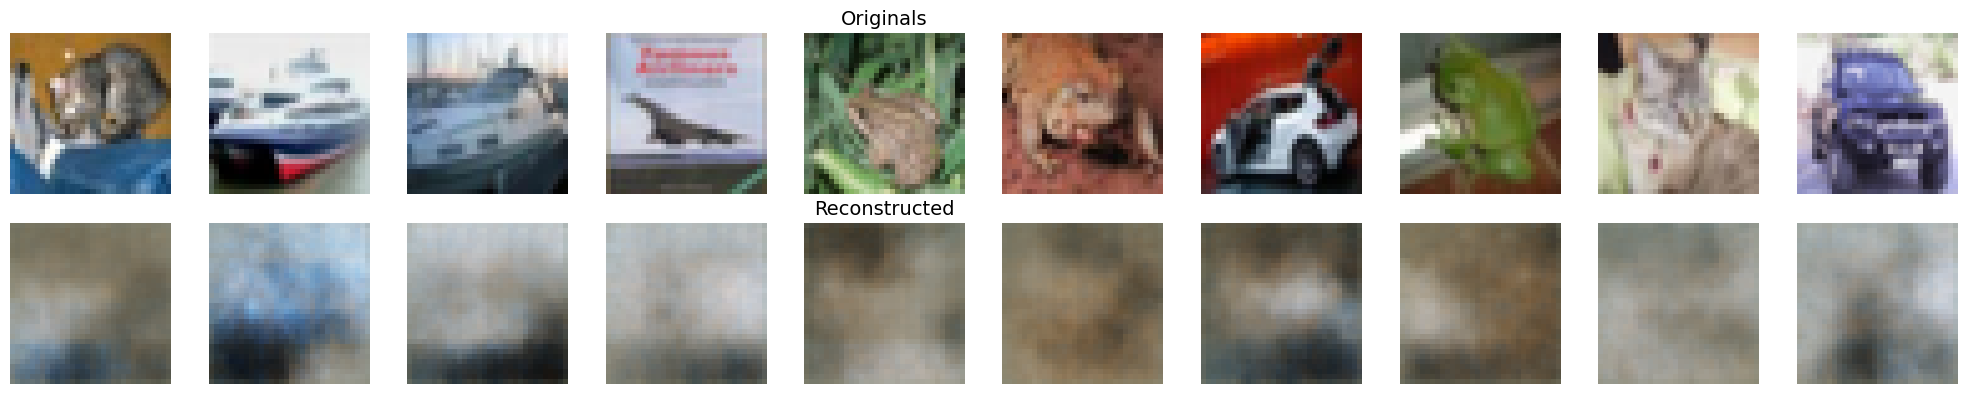

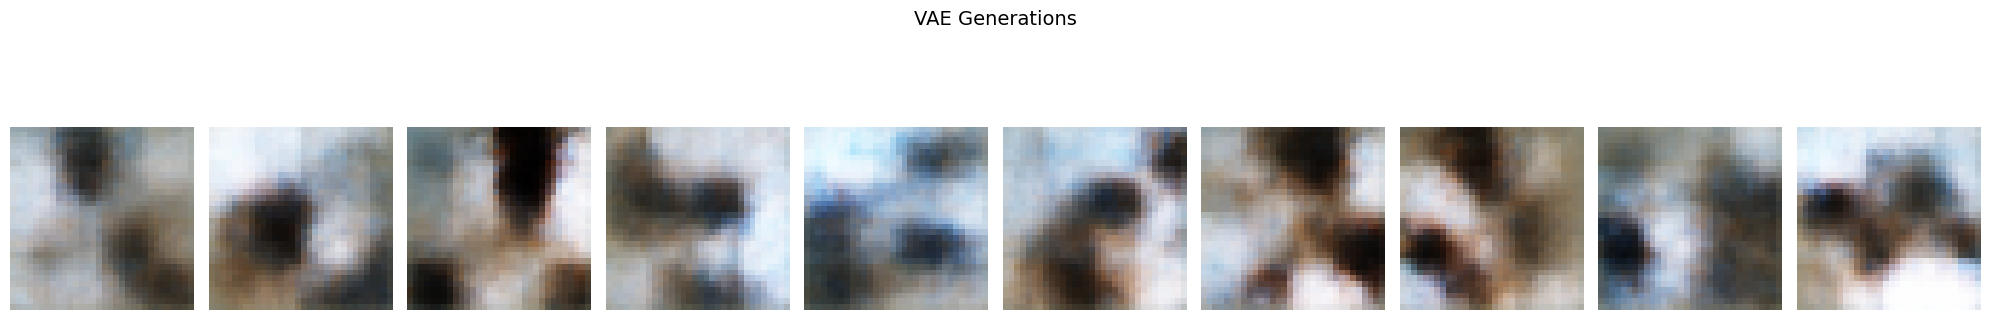

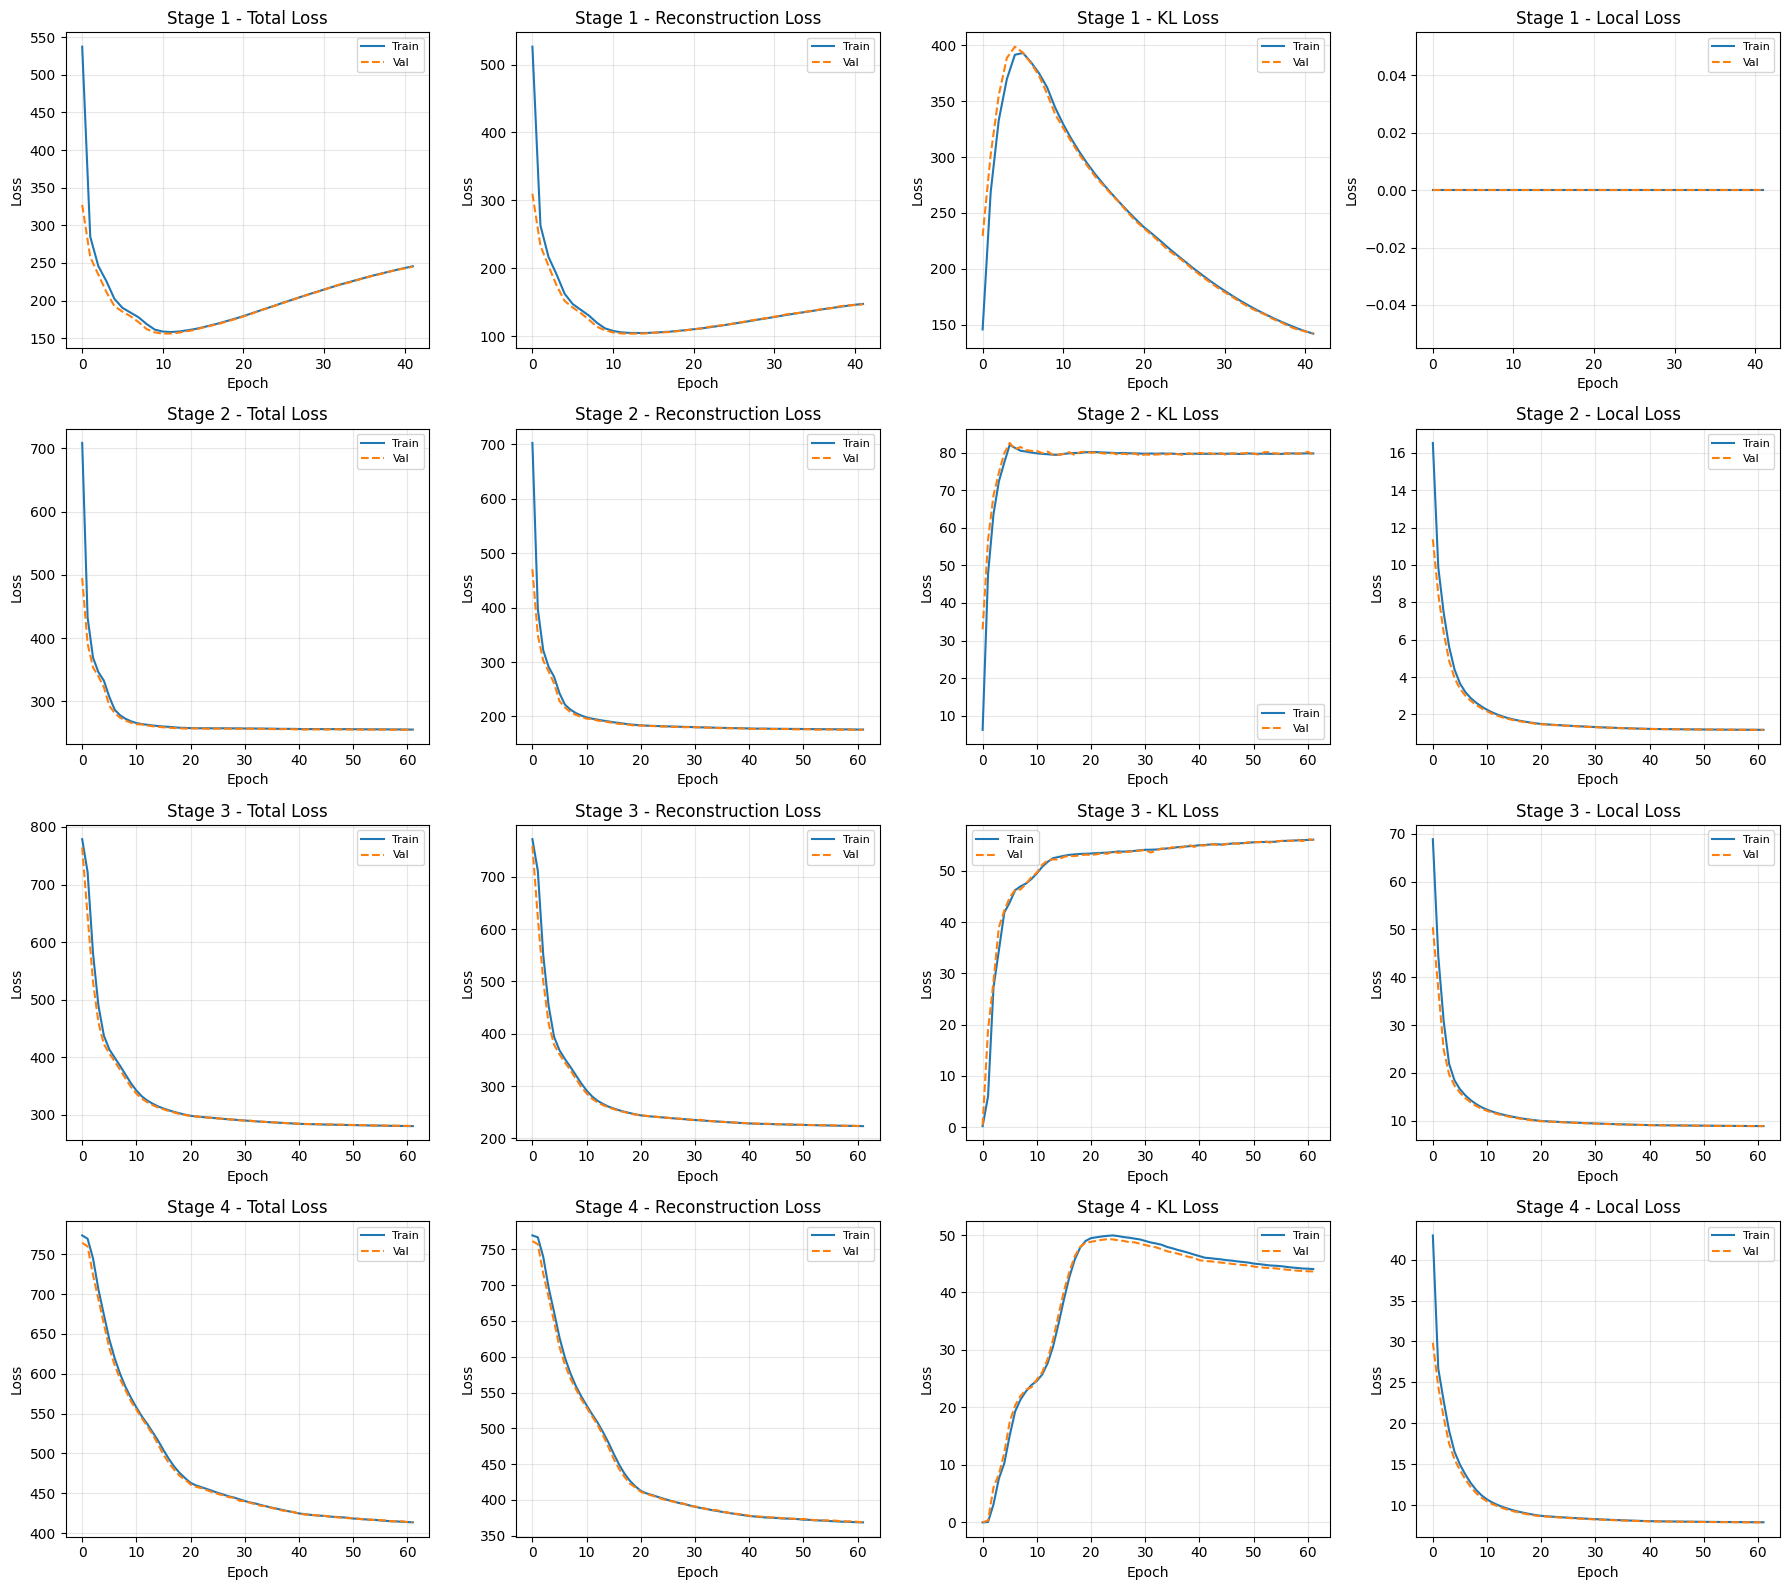

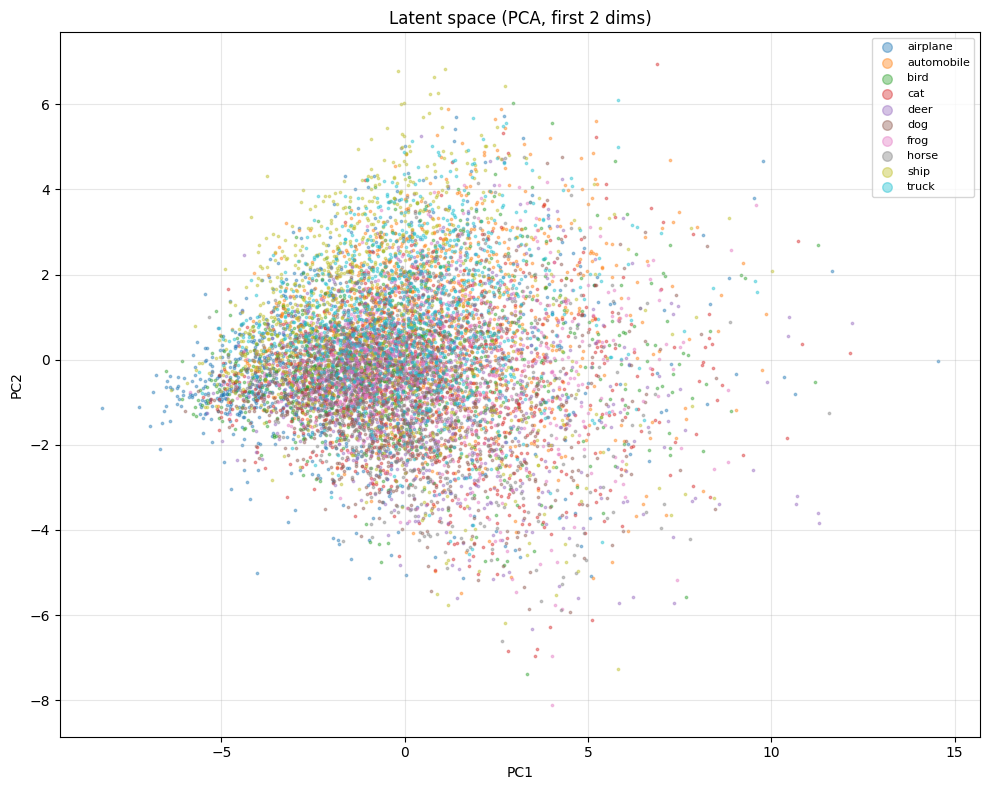

In [5]:
# Cell 5: Visualisations

def display(img):
    # Convert outputs to be displayable images in [0, 1], depending on output activation
    if ACTIVATION_OUT == 'tanh':
        return (np.clip(img, -1, 1) + 1) / 2
    elif ACTIVATION_OUT == 'sigmoid':
        return np.clip(img, 0, 1)

# Reconstructions
test_samples          = x_test[:10]
enc_outputs           = vae.encoder.predict(test_samples, verbose=0)
z_mean, z_log_var, z  = enc_outputs[0], enc_outputs[1], enc_outputs[2]
reconstructed         = vae.decoder.predict(z, verbose=0)
fig, axes             = plt.subplots(2, 10, figsize=(20, 4))
for i in range(10):
    axes[0, i].imshow(display(test_samples[i]))
    axes[0, i].axis('off')
    axes[1, i].imshow(display(reconstructed[i]))
    axes[1, i].axis('off')
axes[0, 4].set_title('Originals',     loc='center', fontsize=14)
axes[1, 4].set_title('Reconstructed', loc='center', fontsize=14)
plt.tight_layout()
plt.show()


# Generations from random latent samples
z_samples = np.random.normal(size=(10, BOTTLENECK_DIM, BOTTLENECK_DIM, LATENT_DIM))
generated = vae.decoder.predict(z_samples, verbose=0)
fig, axes = plt.subplots(1, 10, figsize=(20, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(display(generated[i]))
    ax.axis('off')
plt.suptitle('VAE Generations', fontsize=14)
plt.tight_layout()
plt.show()


# Loss curves per stage
n_stages  = len(histories)
fig, axes = plt.subplots(n_stages, 4, figsize=(18, 4 * n_stages))
panels    = [
    ('Total Loss',          'loss',       'val_loss'),
    ('Reconstruction Loss', 'recon_loss', 'val_recon_loss'),
    ('KL Loss',             'kl_loss',    'val_kl_loss'),
    ('Local Loss',          'local_loss', 'val_local_loss'),
]
for stage_idx, hist in enumerate(histories):
    for col_idx, (title, train_key, val_key) in enumerate(panels):
        ax = axes[stage_idx, col_idx] if n_stages > 1 else axes[col_idx]
        ax.set_title(f'Stage {stage_idx + 1} - {title}')
        if train_key  in hist: ax.plot(hist[train_key], label='Train')
        if val_key    in hist: ax.plot(hist[val_key],   linestyle='--', label='Val')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Latent Space Visualisation
# PCA of the spatial latent space, coloured by class - a well-trained VAE should show smooth, overlapping blobs

(_, y_test_labels) = keras.datasets.cifar10.load_data()[1]

enc_outputs = encoder.predict(x_test, verbose=0)
z_means     = enc_outputs[0]

# Flatten spatial latent map to a vector per sample: (N, H, W, C) -> (N, H*W*C)
z_means_flat = z_means.reshape(z_means.shape[0], -1)

# Manual PCA using NumPy
z_centred            = z_means_flat - z_means_flat.mean(axis=0)
cov                  = np.cov(z_centred, rowvar=False)
eigenvals, eigenvecs = np.linalg.eigh(cov)
# eigh returns ascending order -- take the last 2 (largest variance)
top2 = eigenvecs[:, -2:][:, ::-1]
z_2d = z_centred @ top2

labels          = y_test_labels.flatten()
cifar10_classes = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

plt.figure(figsize=(10, 8))
for cls in range(10):
    mask = labels == cls
    plt.scatter(z_2d[mask, 0], z_2d[mask, 1], s=3, alpha=0.4, label=cifar10_classes[cls])
plt.title('Latent space (PCA, first 2 dims)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(markerscale=4, loc='best', fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
# Cell 6: Metrics

# Final metrics summary
print('\nFinal stage metrics:')
for i, hist in enumerate(histories):
    print(f'  Stage {i+1}: total={hist["loss"][-1]:.5f}, recon={hist["recon_loss"][-1]:.5f}, kl={hist["kl_loss"][-1]:.5f}, local={hist["local_loss"][-1]:.5f}')

print('\nPer-epoch metrics:')

for i, hist in enumerate(histories):
    print(f'\nStage {i+1}')
    
    epochs = list(range(1, len(hist["loss"]) + 1))
    
    # Header row
    print('Epoch :', ' '.join(f'   {e:7d}' for e in epochs))
    print('Total :', ' '.join(f'   {v:7.5}' for v in hist["loss"]))
    print('Recon :', ' '.join(f'   {v:7.5}' for v in hist["recon_loss"]))
    print('KL    :', ' '.join(f'   {v:7.5}' for v in hist["kl_loss"]))
    print('Local :', ' '.join(f'   {v:7.5}' for v in hist["local_loss"]))

# Display full model summary with all layers, including nested encoder and decoder, for final stage
vae.summary(expand_nested=True) 


Final stage metrics:
  Stage 1: total=245.53238, recon=147.41005, kl=141.92810, local=0.00000
  Stage 2: total=255.57642, recon=175.87711, kl=79.82166, local=1.17102
  Stage 3: total=280.50909, recon=223.52148, kl=56.10002, local=8.88786
  Stage 4: total=413.56253, recon=368.69235, kl=44.07801, local=7.92187

Per-epoch metrics:

Stage 1
Epoch :          1          2          3          4          5          6          7          8          9         10         11         12         13         14         15         16         17         18         19         20         21         22         23         24         25         26         27         28         29         30         31         32         33         34         35         36         37         38         39         40         41         42
Total :      537.5     284.78     245.87     225.77     202.18     190.23     183.95     177.63     168.67     161.34     158.75     158.14     158.83     160.37     162.13     164.48     16

Model: "vae_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_L4 (LocalEncoder)       │ ?                      │       155,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ enc_block_0 (Sequential)   │ (1, 16, 16, 16)        │           688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│       └ enc_conv_0 (Conv2D)     │ (1, 16, 16, 16)        │           432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│       └ enc_1x1_0 (Conv2D)      │ (1, 16, 16, 16)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ enc_block_1 (Sequential)   │ (1, 8, 8, 32)          │         5,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│       └ enc_conv_1 (Conv2D)     │ (1, 8, 8, 32)          │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│       └ enc_1x1_1 (Conv2D)      │ (1, 8, 8, 32)          │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ enc_block_2 (Sequential)   │ (1, 4, 4, 64)          │        22,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│       └ enc_conv_2 (Conv2D)     │ (1, 4, 4, 64)          │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│       └ enc_1x1_2 (Conv2D)      │ (1, 4, 4, 64)          │         4,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ enc_block_3 (Sequential)   │ (1, 4, 4, 128)         │        90,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│       └ enc_conv_3 (Conv2D)     │ (1, 4, 4, 128)         │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│       └ enc_1x1_3 (Conv2D)      │ (1, 4, 4, 128)         │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ z_mean (Conv2D)            │ (1, 4, 4, 16)          │        18,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ z_log_var (Conv2D)         │ (1, 4, 4, 16)          │        18,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ sampling_3 (Sampling)      │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_L4 (Functional)         │ (None, 32, 32, 3)      │       225,459 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ input_layer_12             │ (None, 4, 4, 16)       │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ dec_input_proj (Conv2D)    │ (None, 4, 4, 128)      │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ dec_1x1_3 (Conv2D)         │ (None, 4, 4, 128)      │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ dec_convT_3                │ (None, 4, 4, 128)      │       147,456 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ dec_1x1_2 (Conv2D)         │ (None, 4, 4, 64)       │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ dec_convT_2                │ (None, 8, 8, 64)       │        36,864 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,275,086 (4.86 MB)

 Trainable params: 395,699 (1.51 MB)

 Non-trainable params: 87,984 (343.69 KB)

 Optimizer params: 791,403 (3.02 MB)

In [7]:
# Cell 7: Vertical Metrics

# Detailed epoch-by-epoch metrics summary
print('\nPer-epoch metrics:')
for i, hist in enumerate(histories):
    print(f'\nStage {i+1}')
    print('Epoch | Total | Recon | KL')
    print('----------------------------')
  
    for e, (t, r, k) in enumerate(zip(hist["loss"], hist["recon_loss"], hist["kl_loss"])):
        print(f'{e+1:5d} | {t:5.2f} | {r:5.2f} | {k:5.2f}')


Per-epoch metrics:

Stage 1
Epoch | Total | Recon | KL
----------------------------
    1 | 537.50 | 526.44 | 145.68
    2 | 284.78 | 262.83 | 268.56
    3 | 245.87 | 216.58 | 332.95
    4 | 225.77 | 190.77 | 369.73
    5 | 202.18 | 162.31 | 391.61
    6 | 190.23 | 147.20 | 393.24
    7 | 183.95 | 138.71 | 384.92
    8 | 177.63 | 130.33 | 375.01
    9 | 168.67 | 119.63 | 362.40
   10 | 161.34 | 111.42 | 344.25
   11 | 158.75 | 107.59 | 329.38
   12 | 158.14 | 105.57 | 316.33
   13 | 158.83 | 104.70 | 304.71
   14 | 160.37 | 104.58 | 294.01
   15 | 162.13 | 104.57 | 284.30
   16 | 164.48 | 105.02 | 275.53
   17 | 167.18 | 105.79 | 267.21
   18 | 169.84 | 106.49 | 259.26
   19 | 172.94 | 107.64 | 251.58
   20 | 176.03 | 108.77 | 244.28
   21 | 179.30 | 110.10 | 237.23
   22 | 182.89 | 111.47 | 231.41
   23 | 186.52 | 113.05 | 225.27
   24 | 190.09 | 114.76 | 218.93
   25 | 193.68 | 116.51 | 212.88
   26 | 197.49 | 118.51 | 207.11
   27 | 200.86 | 120.29 | 201.17
   28 | 204.42 | 122.23 